# Research for a Telecoms Operator ¶

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget. 

## Objectives ¶

We are going to carry out a preliminary analysis of the Surf and Ultimate plans based on a relatively small client selection. We have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Our job is to analyze clients' behavior and determine which prepaid plan brings in more revenue. 

## Studying the Data
First we'll import the data and have a look at it. There are five datasets: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import math
import numpy as np
from scipy import stats as st
from IPython.display import display

In [2]:
try:
    calls = pd.read_csv('/datasets/megaline_calls.csv')
    internet = pd.read_csv('/datasets/megaline_internet.csv')
    messages = pd.read_csv('/datasets/megaline_messages.csv')
    plans = pd.read_csv('/datasets/megaline_plans.csv')
    users = pd.read_csv('/datasets/megaline_users.csv')
except:
    calls = pd.read_csv('/Users/Steve Lewis/practicum_datasets/megaline_calls.csv')
    internet = pd.read_csv('/Users/Steve Lewis/practicum_datasets/megaline_internet.csv')
    messages = pd.read_csv('/Users/Steve Lewis/practicum_datasets/megaline_messages.csv')
    plans = pd.read_csv('/Users/Steve Lewis/practicum_datasets/megaline_plans.csv')
    users = pd.read_csv('/Users/Steve Lewis/practicum_datasets/megaline_users.csv')

### The 'calls' dataset

In [3]:
display(calls)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72
137731,1499_200,1499,2018-10-20,10.89
137732,1499_201,1499,2018-09-21,8.12
137733,1499_202,1499,2018-10-10,0.37


In [4]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [5]:
calls['duration'].describe()

count    137735.000000
mean          6.745927
std           5.839241
min           0.000000
25%           1.290000
50%           5.980000
75%          10.690000
max          37.600000
Name: duration, dtype: float64

In [6]:
calls.duplicated().sum()

0

Conclusion: This dataset lists all the calls made by this sample of 500 clients in 2018.  It has 137735 rows and no null values.  The duration of calls is measured in minutes and the data seems reasonable.  However, the data type of 'call_date' needs to be changed from object to datetime.

### The 'internet' dataset

In [7]:
display(internet)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06
104821,1499_216,1499,2018-12-30,304.72
104822,1499_217,1499,2018-09-22,292.75
104823,1499_218,1499,2018-12-07,0.00


In [8]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [9]:
internet['mb_used'].describe()

count    104825.000000
mean        366.713701
std         277.170542
min           0.000000
25%         136.080000
50%         343.980000
75%         554.610000
max        1693.470000
Name: mb_used, dtype: float64

In [10]:
len(internet.query('mb_used == 0'))

13747

In [11]:
len(internet.query('mb_used == 0'))/len(internet)

0.1311423801574052

In [12]:
internet.duplicated().sum()

0

Conclusion: This dataset details the internet usage of this sample of 500 clients in 2018. It has 104825 rows and no null values and we notice that 13,737 of the web sessions (13.11%) used no data at all.  Ideally, to confirm if this is legitimate we would need to discuss with the relevant person in the company. However with no further information currently we will assume that the data is correct.

The data type of session_date also needs to be changed from object to datetime.

### The 'messages' dataset

In [13]:
display(messages)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
...,...,...,...
76046,1497_526,1497,2018-12-24
76047,1497_536,1497,2018-12-24
76048,1497_547,1497,2018-12-31
76049,1497_558,1497,2018-12-24


In [14]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [15]:
messages.duplicated().sum()

0

Conclusion: This dataset lists all the messages sent by the sample of 500 clients in 2018. This dataset has 76051 rows and no null values.  The data type of message_date also needs to be changed from object to datetime.

### The 'plans' dataset

In [16]:
display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [17]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


Conclusion: This table details the differences between the surf and the ultimate prepaid plans.

### The 'users' dataset

In [18]:
display(users)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN


In [19]:
users['city'].value_counts()

New York-Newark-Jersey City, NY-NJ-PA MSA          80
Los Angeles-Long Beach-Anaheim, CA MSA             29
Dallas-Fort Worth-Arlington, TX MSA                21
Chicago-Naperville-Elgin, IL-IN-WI MSA             19
Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA    17
                                                   ..
Greensboro-High Point, NC MSA                       1
Raleigh-Cary, NC MSA                                1
Cape Coral-Fort Myers, FL MSA                       1
Stockton, CA MSA                                    1
Albany-Schenectady-Troy, NY MSA                     1
Name: city, Length: 73, dtype: int64

In [20]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [21]:
users.duplicated().sum()

0

Conclusion: This dataset contains information on the sample of 500 clients in 2018.  The data type of reg_date and churn_date will need to be changed from object to datetime.

Note that he churn_date column is poorly populated with only 34 values (ie less than 10%).  Let's look at this data in more detail:

In [22]:
users['churn_date'].value_counts()

2018-12-18    3
2018-12-19    2
2018-11-14    2
2018-12-31    2
2018-11-30    1
2018-10-22    1
2018-12-10    1
2018-12-27    1
2018-12-22    1
2018-07-31    1
2018-12-30    1
2018-08-16    1
2018-09-17    1
2018-11-11    1
2018-11-29    1
2018-10-07    1
2018-09-18    1
2018-11-24    1
2018-11-21    1
2018-11-18    1
2018-12-26    1
2018-10-03    1
2018-12-12    1
2018-08-19    1
2018-09-07    1
2018-12-15    1
2018-11-16    1
2018-09-01    1
2018-10-13    1
Name: churn_date, dtype: int64

These are the dates that the 34 customers ended their plans.  As per the information given with the data, this means that the other 466 customers remained on their plans at least until the end of 2018.

Overall Conclusion: the data has very few errors.  We just need to change the date variables as described above.

## Preparing the Data
Converting the data to the necessary types and eliminating errors in the data.

### Converting the data to the necessary types
We will first change the type of all the date variables to datetime:

In [23]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

In [24]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


The type of call_date has been successfully changed.  Now let's make the other type changes as detailed above:

In [25]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

### Eliminating Errors in the Data
We didn't find any errors with the dataset so there is no need to perform any operations to eliminate errors in the data.

### Calculating New Columns
We will now find the following:
- The number of calls made and minutes used per month for each user
- The number of text messages sent per month for each user
- The volume of data per month for each user
- The monthly revenue from each user (subtract the free package limit from the total number of calls, text messages, and data; multiply the result by the calling plan value; add the monthly charge depending on the calling plan)

### The number of calls made and minutes used per month for each user

We first need to extract the month from 'call_date' and store it in a new column.  Then we need to find the total number of calls and the duration of calls for each user_id for each month. Note that Megaline rounds seconds up to minutes. For calls, each individual call is rounded up: even if the call lasted just one second, it will be counted as one minute. We therefore need to create a new colum with these rounded up call durations.

In [26]:
calls['month'] = pd.DatetimeIndex(calls['call_date']).month

In [27]:
display(calls)

,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,8.52,12
1,1000_145,1000,2018-12-27,13.66,12
2,1000_247,1000,2018-12-27,14.48,12
3,1000_309,1000,2018-12-28,5.76,12
4,1000_380,1000,2018-12-30,4.22,12
...,...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72,11
137731,1499_200,1499,2018-10-20,10.89,10
137732,1499_201,1499,2018-09-21,8.12,9
137733,1499_202,1499,2018-10-10,0.37,10


Now we create the new column with rounded up call durations:

In [28]:
def rounding_up_calls (duration):
    rounding = math.ceil(duration)
    return rounding

In [29]:
calls['duration_rounded_up'] = calls['duration'].apply(rounding_up_calls)

In [30]:
calls.head()

,id,user_id,call_date,duration,month,duration_rounded_up
0,1000_93,1000,2018-12-27,8.52,12,9
1,1000_145,1000,2018-12-27,13.66,12,14
2,1000_247,1000,2018-12-27,14.48,12,15
3,1000_309,1000,2018-12-28,5.76,12,6
4,1000_380,1000,2018-12-30,4.22,12,5


Now we create a table with the durations of calls per user per month (using the rounded up call durations):

In [31]:
calls_pivot = calls.pivot_table(index = ['user_id', 'month'], values = 'duration_rounded_up', aggfunc = ['sum','count'])

In [32]:
calls_pivot.head()

sum               count
              duration_rounded_up duration_rounded_up
user_id month                                        
1000    12                    124                  16
1001    8                     182                  27
        9                     315                  49
        10                    393                  65
        11                    426                  64

In [33]:
calls_pivot.columns = ['minutes_used', 'calls_made']

In [34]:
calls_pivot = calls_pivot.reset_index()

In [35]:
calls_pivot.head()

,user_id,month,minutes_used,calls_made
0,1000,12,124,16
1,1001,8,182,27
2,1001,9,315,49
3,1001,10,393,65
4,1001,11,426,64


In [36]:
calls_pivot.shape

(2258, 4)

### The number of text messages sent per month for each user
Again, we need to extract the month from 'message_date' and store it in a new column.  Then we need to find the total number of messages for each user_id for each month.

In [37]:
messages['month'] = pd.DatetimeIndex(messages['message_date']).month

In [38]:
messages.head()

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


In [39]:
messages_pivot = messages.pivot_table(index = ['user_id', 'month'], values = 'id', aggfunc = 'count')

In [40]:
messages_pivot.head()

id
user_id month    
1000    12     11
1001    8      30
        9      44
        10     53
        11     36

In [41]:
messages_pivot.columns = ['number_of_texts']

In [42]:
messages_pivot.head()

number_of_texts
user_id month                 
1000    12                  11
1001    8                   30
        9                   44
        10                  53
        11                  36

In [43]:
messages_pivot = messages_pivot.reset_index()

In [44]:
messages_pivot.head()

,user_id,month,number_of_texts
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [45]:
messages_pivot.shape

(1806, 3)

### 2.3.3 The Volume of Data per Month for Each User
We will extract the month from 'session_date' and store it in a new column.  Then we will find the total volume of data used (in megabytes) by each user_id each month.

In [46]:
internet['month'] = pd.DatetimeIndex(internet['session_date']).month
internet.head()

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


In [47]:
internet_pivot = internet.pivot_table(index = ['user_id', 'month'], values = 'mb_used', aggfunc = 'sum')
internet_pivot.head()

mb_used
user_id month          
1000    12      1901.47
1001    8       6919.15
        9      13314.82
        10     22330.49
        11     18504.30

In [48]:
internet_pivot.columns = ['volume_of_data_used']
internet_pivot.head()

volume_of_data_used
user_id month                     
1000    12                 1901.47
1001    8                  6919.15
        9                 13314.82
        10                22330.49
        11                18504.30

In [49]:
internet_pivot = internet_pivot.reset_index()
internet_pivot.head()

,user_id,month,volume_of_data_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


In [50]:
internet_pivot.shape

(2277, 3)

Megaline rounds up the total megabytes used for the month per user to gigabytes. We will therefore create a new column in the table with these rounded up values in gigabytes:

In [51]:
def rounding_up (mb):
    rounded = math.ceil(mb/1024)
    return rounded

In [52]:
internet_pivot['data_rounded_up'] = internet_pivot['volume_of_data_used'].apply(rounding_up)

In [53]:
internet_pivot.head()

,user_id,month,volume_of_data_used,data_rounded_up
0,1000,12,1901.47,2
1,1001,8,6919.15,7
2,1001,9,13314.82,14
3,1001,10,22330.49,23
4,1001,11,18504.30,19


### The Monthly Revenue from Each User
To calculate monthly revenue, we first need to join the above three tables together to get the total calls, messages and internet usage by user per month. 

Then we need to add the plan information (ie whether the user was on Surf or Ultimate) and calculate the *chargeable* calls, texts and messages.

First we join the calls and messages table:

In [54]:
calls_and_messages = calls_pivot.merge(messages_pivot, on=['user_id','month'], how='outer')
calls_and_messages.head()

,user_id,month,minutes_used,calls_made,number_of_texts
0,1000,12,124.0,16.0,11.0
1,1001,8,182.0,27.0,30.0
2,1001,9,315.0,49.0,44.0
3,1001,10,393.0,65.0,53.0
4,1001,11,426.0,64.0,36.0


In [55]:
calls_and_messages.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2291 entries, 0 to 2290
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2291 non-null   int64  
 1   month            2291 non-null   int64  
 2   minutes_used     2258 non-null   float64
 3   calls_made       2258 non-null   float64
 4   number_of_texts  1806 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 107.4 KB


Now we join the internet table:

In [56]:
usage_table = calls_and_messages.merge(internet_pivot, on=['user_id','month'], how='outer')
usage_table.head()

,user_id,month,minutes_used,calls_made,number_of_texts,volume_of_data_used,data_rounded_up
0,1000,12,124.0,16.0,11.0,1901.47,2.0
1,1001,8,182.0,27.0,30.0,6919.15,7.0
2,1001,9,315.0,49.0,44.0,13314.82,14.0
3,1001,10,393.0,65.0,53.0,22330.49,23.0
4,1001,11,426.0,64.0,36.0,18504.30,19.0


In [57]:
usage_table.shape

(2293, 7)

Now we will add the plan information.

We will first create a subset of the users table containing the user_id, plan and city columns (as we will need the city column later in the project). Then we will join it to the usage_table.

In [58]:
plans = users[['user_id', 'plan', 'city']]
plans.head()

,user_id,plan,city
0,1000,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,surf,"Seattle-Tacoma-Bellevue, WA MSA"
2,1002,surf,"Las Vegas-Henderson-Paradise, NV MSA"
3,1003,surf,"Tulsa, OK MSA"
4,1004,surf,"Seattle-Tacoma-Bellevue, WA MSA"


In [59]:
users['plan'].value_counts()

surf        339
ultimate    161
Name: plan, dtype: int64

In [60]:
usage_table_plans = usage_table.merge(plans, on=['user_id'], how='outer')
usage_table_plans.head()

,user_id,month,minutes_used,calls_made,number_of_texts,volume_of_data_used,data_rounded_up,plan,city
0,1000,12.0,124.0,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,8.0,182.0,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,9.0,315.0,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,10.0,393.0,65.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,11.0,426.0,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA"


We now need to calculate the 'chargeable' minutes, texts and data for each month.  These are the minutes, texts and data outside of the monthly allowances. 

We will need the following pricing data relating to the two tariffs: Surf and Ultimate.

In [61]:
surf_monthly_charge = 20
surf_monthly_minutes = 500
surf_monthly_messages = 50
surf_monthly_data = 15
surf_call_charge = 0.03
surf_message_charge = 0.03
surf_data_charge = 10

ultimate_monthly_charge = 70
ultimate_monthly_minutes = 3000
ultimate_monthly_messages = 1000
ultimate_monthly_data = 30
ultimate_call_charge = 0.01
ultimate_message_charge = 0.01
ultimate_data_charge = 7

We will define a function to calculate the chargeable minutes, texts and data outside of the monthly allowances:

In [62]:
def chargeable_calls (row):
    plan = row['plan']
    minutes_used = row['minutes_used']
    
    if plan == 'surf':
        if minutes_used > 500:
            chargeable = minutes_used - 500
        else:
            chargeable = 0
    if plan == 'ultimate':
        if minutes_used > 3000:
            chargeable = minutes_used - 3000
        else:
            chargeable = 0
    return chargeable

In [63]:
usage_table_plans['chargeable_calls'] = usage_table_plans.apply(chargeable_calls, axis =1)
usage_table_plans.head()

,user_id,month,minutes_used,calls_made,number_of_texts,volume_of_data_used,data_rounded_up,plan,city,chargeable_calls
0,1000,12.0,124.0,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",0.0
1,1001,8.0,182.0,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0
2,1001,9.0,315.0,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0
3,1001,10.0,393.0,65.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0
4,1001,11.0,426.0,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0


The new column has beed added successfully.  We will investigate it further:

In [64]:
len(usage_table_plans.query('chargeable_calls != 0'))

566

In [65]:
usage_table_plans.query('chargeable_calls != 0')['chargeable_calls'].describe()

count     566.000000
mean      170.803887
std       158.523426
min         1.000000
25%        62.000000
50%       126.000000
75%       225.000000
max      1010.000000
Name: chargeable_calls, dtype: float64

We see that there were 566 user-months in the period when the company earned additonal income from calls.

Now we will calculate and add similar columns for messages and data.

In [66]:
def chargeable_messages (row):
    plan = row['plan']
    number_of_texts = row['number_of_texts']
    
    if plan == 'surf':
        if number_of_texts > 50:
            chargeable = number_of_texts - 50
        else:
            chargeable = 0
    if plan == 'ultimate':
        if number_of_texts > 1000:
            chargeable = number_of_texts - 1000
        else:
            chargeable = 0
    return chargeable

In [67]:
usage_table_plans['chargeable_messages'] = usage_table_plans.apply(chargeable_messages, axis =1)
usage_table_plans.head()

,user_id,month,minutes_used,calls_made,number_of_texts,volume_of_data_used,data_rounded_up,plan,city,chargeable_calls,chargeable_messages
0,1000,12.0,124.0,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",0.0,0.0
1,1001,8.0,182.0,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0
2,1001,9.0,315.0,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0
3,1001,10.0,393.0,65.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,3.0
4,1001,11.0,426.0,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0


In [68]:
def chargeable_data (row):
    plan = row['plan']
    data_rounded_up = row['data_rounded_up']
    
    if plan == 'surf':
        if data_rounded_up > 15:
            chargeable = data_rounded_up - 15
        else:
            chargeable = 0
    if plan == 'ultimate':
        if data_rounded_up > 30:
            chargeable = data_rounded_up - 30
        else:
            chargeable = 0
    return chargeable

In [69]:
usage_table_plans['chargeable_data'] = usage_table_plans.apply(chargeable_data, axis =1)
usage_table_plans.head()

,user_id,month,minutes_used,calls_made,number_of_texts,volume_of_data_used,data_rounded_up,plan,city,chargeable_calls,chargeable_messages,chargeable_data
0,1000,12.0,124.0,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",0.0,0.0,0.0
1,1001,8.0,182.0,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0,0.0
2,1001,9.0,315.0,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0,0.0
3,1001,10.0,393.0,65.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,3.0,8.0
4,1001,11.0,426.0,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0,4.0


Now we have all the data we need to calculate and add a monthly revenue column:

In [70]:
def monthly_rev(row):
    plan = row['plan']
    chargeable_calls = row['chargeable_calls']
    chargeable_messages = row['chargeable_messages']
    chargeable_data = row['chargeable_data']
    
    if plan == 'surf':
        revenue = surf_monthly_charge +((chargeable_calls * surf_call_charge) + (chargeable_messages * surf_message_charge)+ (chargeable_data * surf_data_charge))
    else:
        revenue = ultimate_monthly_charge +((chargeable_calls * ultimate_call_charge) + (chargeable_messages * ultimate_message_charge)+ (chargeable_data * ultimate_data_charge))
    return revenue

In [71]:
usage_table_plans['monthly_revenue'] = usage_table_plans.apply(monthly_rev, axis =1)
usage_table_plans.head()

,user_id,month,minutes_used,calls_made,number_of_texts,volume_of_data_used,data_rounded_up,plan,city,chargeable_calls,chargeable_messages,chargeable_data,monthly_revenue
0,1000,12.0,124.0,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",0.0,0.0,0.0,70.00
1,1001,8.0,182.0,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0,0.0,20.00
2,1001,9.0,315.0,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0,0.0,20.00
3,1001,10.0,393.0,65.0,53.0,22330.49,23.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,3.0,8.0,100.09
4,1001,11.0,426.0,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",0.0,0.0,4.0,60.00


The 'usage_table_plans' dataset now gives us the information requested: 
- The number of calls made and minutes used per month
- The number of text messages sent per month
- The volume of data per month
- The monthly revenue from each user.

## Analysing the Data
We will now investigate the customers' behavior by plotting histograms of the minutes, texts and volume of data the users of each plan require per month. 
We will also calculate the mean, variance and standard deviation.

In [72]:
variables = ['minutes_used', 'number_of_texts', 'volume_of_data_used']
plans = ['surf', 'ultimate']

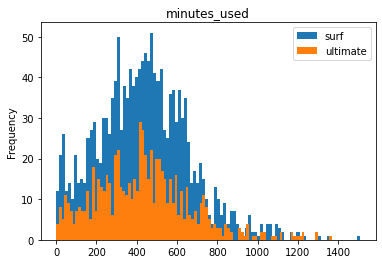

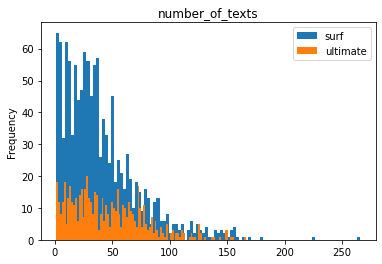

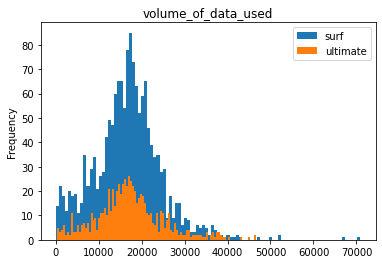

In [73]:
for col in variables:
    for tariff in plans:
        usage_table_plans[usage_table_plans['plan'] == tariff][col].plot(kind = 'hist', bins = 100)
    plt.title(col)
    plt.legend(plans)
    plt.show()

These graphs plot the distributions of the monthly consumption by users of call minutes, messages and data. The data covers 500 users, 339 on the surf plan and 161 on the ultimate plan. 

### Analysis of Call Minutes used

In [74]:
usage_table_plans.query('plan == "surf"')['minutes_used'].max()

1510.0

In [75]:
usage_table_plans.query('plan == "ultimate"')['minutes_used'].max()

1369.0

In [76]:
usage_table_plans.query('plan == "surf"')['minutes_used'].mean()

436.51974110032364

In [77]:
usage_table_plans.query('plan == "surf"')['minutes_used'].median()

430.0

In [78]:
usage_table_plans.query('plan == "ultimate"')['minutes_used'].mean()

434.67601683029454

In [79]:
usage_table_plans.query('plan == "ultimate"')['minutes_used'].median()

425.0

In [80]:
np.var(usage_table_plans.query('plan == "surf"')['minutes_used'])

52537.03666530514

In [81]:
np.std(usage_table_plans.query('plan == "surf"')['minutes_used'])

229.20959112852398

In [82]:
np.var(usage_table_plans.query('plan == "ultimate"')['minutes_used'])

56494.28633925359

In [83]:
np.std(usage_table_plans.query('plan == "ultimate"')['minutes_used'])

237.68526740051345

Analysis: The distribution of minutes used per month seems to approximate a 'normal' distribution for both the Surf and Ultimate plans.  They both look to be skewed to the right and this is confirmed by the means of each being higher than the medians. The mean for Surf is 436.5 minutes and for Ultimate 434.7 minutes.  The maximum monthly usage for those on the Surf plan (in this sample) was 1510 minutes, compared to 1369 for the Ultimate plan. The standard deviation for Ultimate is 237.7 which is greater than the variance for Surf (at 229.2).

### Analysis of Text Messages Sent

In [84]:
usage_table_plans.query('plan == "surf"')['number_of_texts'].mean()

40.10965630114566

In [85]:
usage_table_plans.query('plan == "ultimate"')['number_of_texts'].mean()

46.29623287671233

In [86]:
np.var(usage_table_plans.query('plan == "surf"')['number_of_texts'])

1090.4511506183685

In [87]:
np.var(usage_table_plans.query('plan == "ultimate"')['number_of_texts'])

1083.3249173156314

In [88]:
np.std(usage_table_plans.query('plan == "surf"')['number_of_texts'])

33.02197981070137

In [89]:
np.std(usage_table_plans.query('plan == "ultimate"')['number_of_texts'])

32.91390158148425

Analysis: The distribution of the number of texts sent per month looks less like a 'normal' distribution and more like a downward exponential curve for both the Surf and Ultimate plans.  
The mean for Surf is 40.1 texts per month and for ultimate is higher at 46.2 texts per month.  
The standard deviations for both plans are very similar: 33.0 for Surf and 32.9 for Ultimate.

### Analysis of Data Used (mb)

In [90]:
usage_table_plans.query('plan == "surf"')['volume_of_data_used'].mean()

16717.702137355584

In [91]:
usage_table_plans.query('plan == "ultimate"')['volume_of_data_used'].mean()

17238.642253129346

In [92]:
np.var(usage_table_plans.query('plan == "surf"')['volume_of_data_used'])

62128323.16300871

In [93]:
np.var(usage_table_plans.query('plan == "ultimate"')['volume_of_data_used'])

61239556.12006475

In [94]:
np.std(usage_table_plans.query('plan == "surf"')['volume_of_data_used'])

7882.152191058525

In [95]:
np.std(usage_table_plans.query('plan == "ultimate"')['volume_of_data_used'])

7825.57065779006

Analysis: The distribution of the volume of data used per month looks very much like a 'normal' distribution for both the Surf and Ultimate plans.
The mean for Ultimate is higher at 17,238mb compared to 16,717mb for Surf.
However, the standard deviations for both plans are very similar: 7,882mb for Surf and 7,825mb for Ultimate.

Conclusion: the behavious of customers on the Surf and Ultimate plans is actually quite similar.  Despite the Ultimate plan being more expensive and having greater allowances, Surf customer use slightly more call minutes per month, on average.  Ultimate customers send more text messages on average than Surf customers (46.2 compared to 40.1) and the standard deviations for both are similar.  Ultimate customers do use more data per month that Surf customers, but not significantly more: 17.2GB compared to 16.7GB. Again, the standard deviations for both are very similar.

## Testing Hypotheses
We will now test the following hypotheses:
- Hypothesis 1: The average revenue from users of Ultimate and Surf calling plans differs.
- Hypothesis 2: The average revenue from users in NY-NJ area is different from that of the users from other regions.

### Hypothesis 1
We will compare the means of the two plans and test the hypothesis that the average revenue from users of Ultimate and Surf calling plans differs (ie that one could be greater or less than the other).  This is a 2 sided test from data for two independent data sources. 

In [96]:
usage_table_plans.query('plan == "surf"')['monthly_revenue'].mean()

63.445965801139955

In [97]:
usage_table_plans.query('plan == "ultimate"')['monthly_revenue'].mean()

72.6878453038674

In [98]:
np.std(usage_table_plans.query('plan == "surf"')['monthly_revenue'])

57.342719806070754

In [99]:
np.std(usage_table_plans.query('plan == "ultimate"')['monthly_revenue'])

12.630832061337228

The average monthly revenue for Ultimate customers (72.69 USD) appears greater than for Surf customers (63.44 USD). However, the standard distributions are very different, so we will formulate a null and alternative hypothesis and use the data sets to perform a statistical test.

The null hypothesis will be: 'the means of the two datasets are equal'. We will use a critical statistical significance level (alpha) of 0.05.  If the p-value < alpha, we reject the hypothesis that the mean monthly revenues of the two customer groups are equal.

In [100]:
alpha = 0.05
sample_1 = usage_table_plans.query('plan == "surf"')['monthly_revenue']
sample_2 = usage_table_plans.query('plan == "ultimate"')['monthly_revenue']
results = st.ttest_ind(sample_1, sample_2, equal_var = False) 
# we set equal_var to False as we don't consider the variances of the statistical populations from which the samples are taken to be are approximately equal.

print('p-value: ', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis") 

p-value:  1.3814968413089234e-09
We reject the null hypothesis


The p-value is very small.  It tells us that if the means of the two datasets were indeed the same, only around a 0.000001% of the values would have the same mean. That is, there is a very small probability of them randomly being the same. This probability is low enough to conclude that **we can reject the null hypothesis that the average revenues are the same for both groups**. So yes, it is probable that the average revenue from Users of Surf and Ultimate dies indeed differ.

### Hypothesis 2
We will examine the claim that the average revenue from users in NY-NJ area is different from that of the users from other regions. We will compare the means of the groups. This is  a 2 sided test for paired samples.

In [101]:
usage_table_plans['city'].value_counts()

New York-Newark-Jersey City, NY-NJ-PA MSA          378
Los Angeles-Long Beach-Anaheim, CA MSA             132
Chicago-Naperville-Elgin, IL-IN-WI MSA              94
Dallas-Fort Worth-Arlington, TX MSA                 89
Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA     82
                                                  ... 
Omaha-Council Bluffs, NE-IA MSA                      3
Raleigh-Cary, NC MSA                                 2
El Paso, TX MSA                                      2
Jacksonville, FL MSA                                 2
Cape Coral-Fort Myers, FL MSA                        1
Name: city, Length: 73, dtype: int64

In [102]:
NY_NJ = usage_table_plans[usage_table_plans['city'].str.contains('NY-NJ')]
len(NY_NJ)

378

We will compare the data from users in the 'New York-Newark-Jersey City, NY-NJ-PA MSA' to the others in the dataset.

In [103]:
Not_NY_NJ = usage_table_plans.query('city not in @NY_NJ.city')
len(Not_NY_NJ)

1925

In [104]:
len(usage_table_plans)

2303

As 2303 = 378 + 1925, we have successfully split our dataset along the NY-NJ border.

We will formulate a null and alternative hypothesis and use the data sets to perform a statistical test.

The null hypothesis will again be: 'the means of the two datasets are equal'. We will again use a critical statistical significance level (alpha) of 0.05.  If the p-value < alpha, we reject the hypothesis that the mean monthly revenues of the two customer groups are equal.

In [105]:
alpha = 0.05
sample_3 = NY_NJ['monthly_revenue']
sample_4 = Not_NY_NJ['monthly_revenue']

results1 = st.ttest_ind(sample_3, sample_4)

print('p-value: ', results1.pvalue)

if results1.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis") 

p-value:  0.11159739579354931
We can't reject the null hypothesis


This time the p-value is greater than alpha, the critical statistical significance level. This states that if the means of the two datasets were indeed the same, 11.1% of the random samples would have the same mean.  Given this, **we cannot reject the null hypothesis that the average revenue from users in the NY-NJ area is the same as that of users in other regions**. So we cannot say that the averages are different in the two geographical regions.

## Overall Conclusion
In this project we analysed a sample of customer data of  of telecom operator Megaline which offers its clients two prepaid plans, Surf and Ultimate.  Our job was to analyze clients' behavior and determine which prepaid plan brings in more revenue. 

The distribution of call minutes used per month seemed to approximate a 'normal' distribution for both the Surf and Ultimate plans.  The mean call minutes used per month for Surf is 436.5 minutes and for Ultimate 434.7 minutes.  The maximum monthly usage for those on the Surf plan in this sample was 1510 minutes, compared to 1369 for the Ultimate plan. The standard deviation for Ultimate is 237.7 which is greater than the variance for Surf (at 229.2).

The distribution of the number of texts sent per month looked less like a 'normal' distribution. The mean for Surf is 40.1 texts per month and for ultimate is higher at 46.2 texts per month.  The standard deviations however for both plans are very similar: 33.0 for Surf and 32.9 for Ultimate.

The distribution of the volume of data used per month looks very much like a 'normal' distribution for both the Surf and Ultimate plans. The mean for Ultimate is higher at 17,238mb compared to 16,717mb for Surf. However, the standard deviations for both plans are very similar: 7,882mb for Surf and 7,825mb for Ultimate.

We conclude that the behaviour of customers on the Surf and Ultimate plans is very similar. Despite the Ultimate plan being more expensive and having greater allowances, Surf customer use slightly more call minutes per month, on average. Ultimate customers do use more data per month that Surf customers, but not significantly more: 17.3GB compared to 16.7GB. Again, the standard deviations for both are very similar.  

Given this it would appear that the Ulimate plan should be more profitable and we discovered that the mean revenue from Surf is 63.44USD and from Ultimate 72.68USD. Given however that the standard deviations for each are very different (57.34USD for Surf and 12.63USD for Ultimate) we ran a statistical test to check the probability that the means were indeed different.

We concluded, given the low p-value that there is a very small probability of them randomly being the same. This probability was low enough to conclude that we can reject the probability that the average revenues are the same for both groups. So yes, **it is probable that the average revenue from Users of Surf and Ultimate does differ**.

We than ran a second statistical test to check if the average revenue from users in NY-NJ area is different from that of the users from other regions. This time the p-value was higher than the critical statistical significance level. Given this, we could not reject the null hypothesis that the average revenue from users in the NY-NJ area is the same as that of users in other regions. So **we cannot say that the averages are different in the two geographical regions**.